In [2]:
import pandas as pd
import numpy as np

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('data_science_job.csv')

In [5]:
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 3.2 MB


In [15]:
data.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [16]:
col = [col for col in data.columns if data[col].isnull().mean() < 0.05 and data[col].isnull().mean() > 0]

col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

<Axes: xlabel='education_level'>

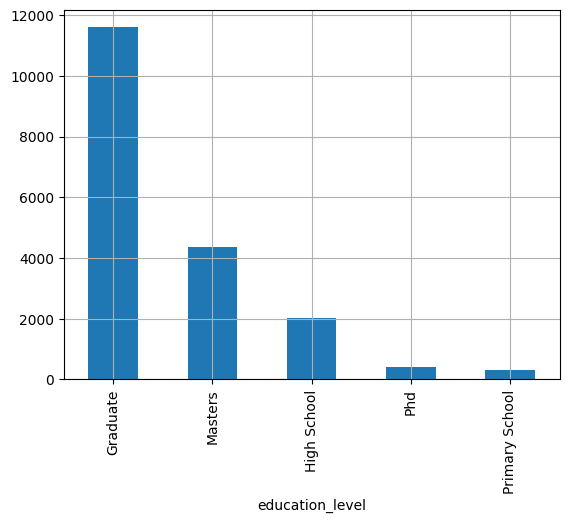

In [23]:
data['education_level'].value_counts().sort_values(ascending=False).plot(kind='bar', grid=True)

<Axes: xlabel='enrolled_university'>

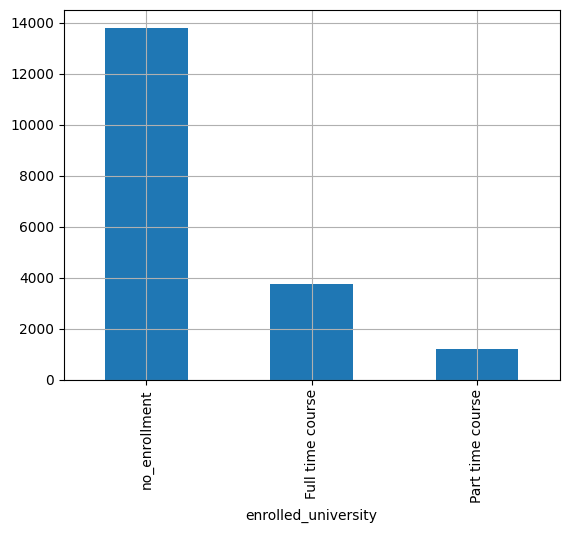

In [24]:
data['enrolled_university'].value_counts().sort_values(ascending=False).plot(kind='bar', grid=True)

In [25]:
data['education_level'].mode()

0    Graduate
Name: education_level, dtype: str

In [26]:
data['enrolled_university'].mode()

0    no_enrollment
Name: enrolled_university, dtype: str

Text(0.5, 1.0, 'Education Level')

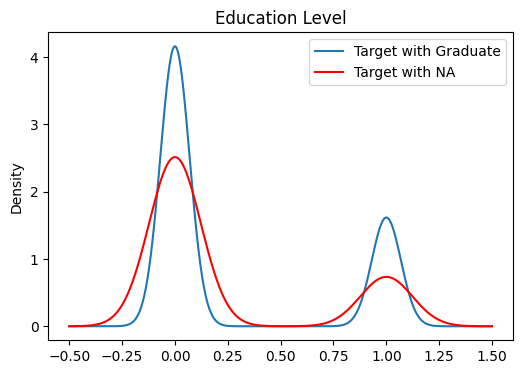

In [30]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

data[data['education_level']=='Graduate']['target'].plot(kind='kde', ax=ax)
data[data['education_level'].isnull()]['target'].plot(kind='kde', ax=ax, color='red')


lines, labels = ax.get_legend_handles_labels()
labels = ['Target with Graduate', 'Target with NA']
ax.legend(lines, labels, loc='best')

plt.title('Education Level')


In [33]:
new_data = data[data['education_level'] == 'Graduate']['target']

new_data

0        1.0
1        0.0
2        0.0
3        1.0
5        1.0
        ... 
19151    0.0
19152    0.0
19153    1.0
19154    1.0
19155    0.0
Name: target, Length: 11598, dtype: float64

In [34]:
data['education_level'].fillna('Graduate', inplace=True)

/var/folders/5j/8mqwh5x92_v5bzym81m371mh0000gn/T/ipykernel_27257/1383222481.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['education_level'].fillna('Graduate', inplace=True)


0              Graduate
1              Graduate
2              Graduate
3              Graduate
4               Masters
              ...      
19153          Graduate
19154          Graduate
19155          Graduate
19156       High School
19157    Primary School
Name: education_level, Length: 19158, dtype: str

<Axes: xlabel='education_level'>

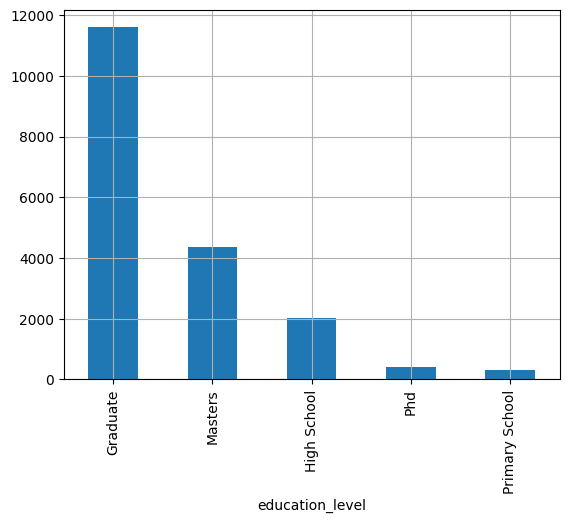

In [35]:
data['education_level'].value_counts().sort_values(ascending=False).plot(kind='bar', grid=True)

Text(0.5, 1.0, 'Education Level')

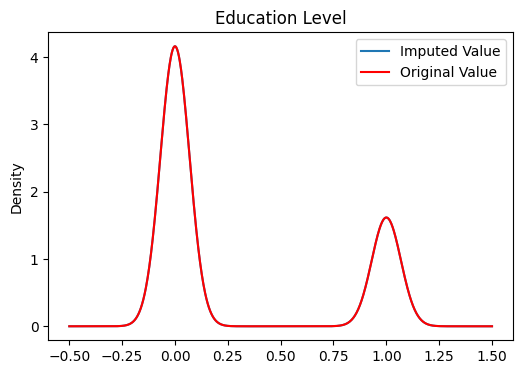

In [36]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

data[data['education_level']=='Graduate']['target'].plot(kind='kde', ax=ax)
new_data.plot(kind='kde', ax=ax, color='red')


lines, labels = ax.get_legend_handles_labels()
labels = ['Imputed Value', 'Original Value']
ax.legend(lines, labels, loc='best')

plt.title('Education Level')


## Imputing for 'enrolled_university'

Text(0.5, 1.0, 'Education Level')

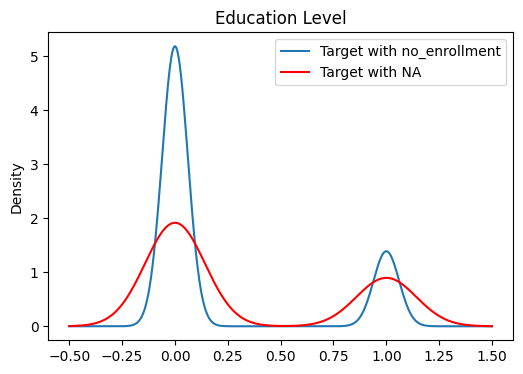

In [38]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

data[data['enrolled_university']=='no_enrollment']['target'].plot(kind='kde', ax=ax)
data[data['enrolled_university'].isnull()]['target'].plot(kind='kde', ax=ax, color='red')


lines, labels = ax.get_legend_handles_labels()
labels = ['Target with no_enrollment', 'Target with NA']
ax.legend(lines, labels, loc='best')

plt.title('Education Level')


In [39]:
new_data = data[data['enrolled_university']=='no_enrollment']['target']

new_data

0        1.0
1        0.0
4        0.0
6        0.0
7        1.0
        ... 
19153    1.0
19154    1.0
19155    0.0
19156    0.0
19157    0.0
Name: target, Length: 13817, dtype: float64

In [40]:
data['enrolled_university'].fillna('no_enrollment', inplace=True)

/var/folders/5j/8mqwh5x92_v5bzym81m371mh0000gn/T/ipykernel_27257/1291927609.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['enrolled_university'].fillna('no_enrollment', inplace=True)


0           no_enrollment
1           no_enrollment
2        Full time course
3           no_enrollment
4           no_enrollment
               ...       
19153       no_enrollment
19154       no_enrollment
19155       no_enrollment
19156       no_enrollment
19157       no_enrollment
Name: enrolled_university, Length: 19158, dtype: str

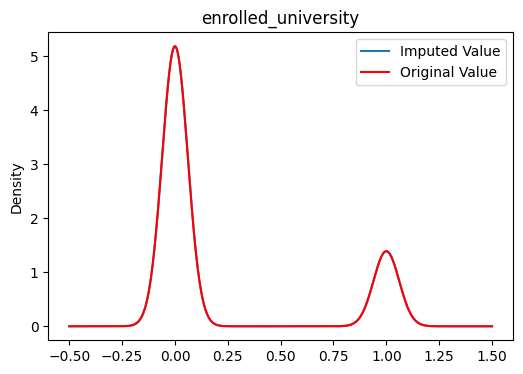

In [45]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

data[data['enrolled_university']=='no_enrollment']['target'].plot(kind='kde', ax=ax)
new_data.plot(kind='kde', ax=ax, color='red')


lines, labels = ax.get_legend_handles_labels()
labels = ['Imputed Value', 'Original Value']
ax.legend(lines, labels, loc='best')

plt.title('enrolled_university')

plt.show()
